## Process GloFAS ensemble reforecast data to identify extreme rainfall events in Dublin 

In [1]:
import glob
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging
from pathlib import Path
import time

### Processing steps

- Read in nc file 
- Rank the run/lead time combinations to find the largest spread (return the top 50 dates)
- Cross-check with GloFAS reanalysis to see whether these were real events 

In [42]:
file_path = '/mnt/metdata/W25-2348/glofas/processed_spread'
files = sorted(glob.glob(f"{file_path}/glofas_spread_*.nc"))
records = []
for f in files:
    ds = xr.open_dataset(f)
    da = ds["spread_maxmin"]   # dims time, step
    # convert to dataframe for this file
    df = da.to_dataframe(name="spread").reset_index()   # time, step, spread
    df = df.dropna(subset=["spread"])
    df["year_file"] = f
    records.append(df)

df_all = pd.concat(records, ignore_index=True)

# convert step to hours
if pd.api.types.is_timedelta64_dtype(df_all["step"].dtype):
    df_all["lead_hours"] = df_all["step"].dt.total_seconds() / 3600.0

### TODO: add simple code here to filter out events with lead time > 5 days 

In [43]:
df_all

,time,step,spread,year_file,lead_hours
0,2003-03-27,1 days,5.468750,/mnt/metdata/W25-2348/glofas/processed_spread/...,24.0
1,2003-03-27,2 days,6.843750,/mnt/metdata/W25-2348/glofas/processed_spread/...,48.0
2,2003-03-27,3 days,6.500000,/mnt/metdata/W25-2348/glofas/processed_spread/...,72.0
3,2003-03-27,4 days,5.625000,/mnt/metdata/W25-2348/glofas/processed_spread/...,96.0
4,2003-03-27,5 days,4.718750,/mnt/metdata/W25-2348/glofas/processed_spread/...,120.0
...,...,...,...,...,...
31423,2023-11-25,5 days,3.488281,/mnt/metdata/W25-2348/glofas/processed_spread/...,120.0
31424,2023-11-25,6 days,6.582031,/mnt/metdata/W25-2348/glofas/processed_spread/...,144.0
31425,2023-11-25,7 days,10.734375,/mnt/metdata/W25-2348/glofas/processed_spread/...,168.0
31426,2023-11-25,8 days,11.562500,/mnt/metdata/W25-2348/glofas/processed_spread/...,192.0


In [ ]:
# sort and save
df_sorted = df_all.sort_values("spread", ascending=False).reset_index(drop=True)
df_sorted.head(50).to_csv(f"{file_path}/glofas_ensemble_reforecast_spread_top50.csv", index=False)

In [41]:
ds = xr.open_dataset('/mnt/metdata/W25-2348/glofas/processed_spread/glofas_spread_2015.nc')
da = ds['spread_maxmin']
df = da.to_dataframe(name="spread").reset_index()
df = df.dropna(subset=['spread'])
df = df.sort_values('spread', ascending=False).reset_index(drop=True)
df

,time,step,spread
0,2015-08-22,3 days,177.843750
1,2015-08-22,4 days,153.515625
2,2015-08-28,4 days,145.343750
3,2015-12-25,6 days,139.875000
4,2015-08-28,5 days,137.203125
...,...,...,...
1570,2015-03-14,1 days,0.000000
1571,2015-09-26,1 days,0.000000
1572,2015-09-28,1 days,0.000000
1573,2015-02-08,1 days,0.000000


### Calculate largest ensemble spread per lead time

In [3]:
largest_spread_index_per_lead_time = df_all.groupby("step")["spread"].idxmax()
largest_spread_per_lead_time = df_all.loc[largest_spread_index_per_lead_time].sort_values("step")
largest_spread_per_lead_time.to_csv(f'{file_path}/largest_ensemble_spread_per_lead_time.csv', index=False)

### Top 5 dates per lead time

In [4]:
df_all['lead_days'] = df_all['step'].dt.days
df_all['lead_str'] = df_all['lead_days'].astype(str) + 'd'
for lead_time in df_all['lead_str'].unique():
    df_all[df_all['lead_str'] == lead_time].sort_values("spread", ascending=False).head(5).reset_index(drop=True).to_csv(f'{file_path}/top5_per_lead_time_{lead_time}.csv')

## Read in GloFAS historical data

In [5]:
logging.basicConfig(level=logging.INFO)

def open_monthly_gribs(folder, pattern="*_*/data.grib", varname=None, chunks=None):
    """
    Open multiple monthly GRIB files in `folder` (wildcard pattern relative to folder).
    - pattern: default matches folders like 2019_01/data.grib (use 'data.grib' if files are directly inside)
    - varname: if given, select that variable early (faster & avoids variable name conflicts)
    - chunks: dict for dask chunking, e.g. {'time': 175, 'step': 1}
    Returns xarray.Dataset (lazy).
    """
    files = sorted(glob.glob(str(folder) + "/" + pattern))
    if not files:
        raise FileNotFoundError("No files found with pattern: " + str(folder) + "/" + pattern)
    logging.info("Found %d files", len(files))

    try:
        logging.info("Trying open_mfdataset with cfgrib ...")
        ds = xr.open_mfdataset(
            files,
            engine="cfgrib",
            combine="by_coords",
            parallel=True,
            chunks=chunks,
            backend_kwargs={"indexpath": ""}   # avoid .idx files; optional
        )
        if varname:
            ds = ds[[varname]]  # select variable early
        return ds
    except Exception as e:
        logging.warning("open_mfdataset failed: %s. Falling back to per-file open+concat", e)

    # fallback: open each file and concat
    datasets = []
    for f in files:
        logging.info("Opening %s", f)
        dsf = xr.open_dataset(f, engine="cfgrib", backend_kwargs={"indexpath": ""})
        if varname:
            dsf = dsf[[varname]]
        datasets.append(dsf)
    logging.info("Concatenating %d datasets along time", len(datasets))
    ds = xr.concat(datasets, dim="time", combine_attrs="override", data_vars="minimal", coords="minimal")
    return ds

ds_hist = open_monthly_gribs("/mnt/metdata/W25-2348/glofas/historical_reanalysis", pattern="cems-glofas-historical*/data.grib", varname="dis24", chunks={'time':175,'step':1})

INFO:root:Found 251 files
INFO:root:Trying open_mfdataset with cfgrib ...


### Process the GloFAS historical data 

- Analyse the same grid point as for the reforecast 
- Compare time series for the high-spread events we've identified 

In [6]:
da = ds_hist['dis24'].sel(latitude=53.375,method='nearest').sel(longitude=353.625,method='nearest')

### Calculate some useful statistics 

- Maximum values and percentiles 

In [ ]:
dis_max = da.values.max()

np.float32(86.828125)

In [32]:
q25 = np.nanpercentile(da, 25, axis=0)
q50 = np.nanpercentile(da, 50, axis=0)
q75 = np.nanpercentile(da, 75, axis=0)

In [34]:
dis_mean = da.values.mean()

In [35]:
q25, q50, q75, dis_mean

(np.float32(6.0625),
 np.float32(10.0),
 np.float32(15.0625),
 np.float32(12.024065))

## Plot time-series for ensemble members for the 22 August 2015 event 

- See cells below for a quick comparison with GloFAS reanalysis data 
- The event was characterised by large ensemble spread but low river flow
- Produce a time-series of the ensemble members at the grid point around the time of the event to examine the spread in more detail   

In [36]:
file_path = '/mnt/metdata/W25-2348/glofas/processed_spread/glofas_spread_2015.nc'
ds = xr.open_dataset(file_path)
ds

<xarray.Dataset> Size: 27kB
Dimensions:        (time: 175, step: 9)
Coordinates:
  * time           (time) datetime64[ns] 1kB 2015-01-01 ... 2015-12-28
  * step           (step) timedelta64[ns] 72B 1 days 2 days ... 8 days 9 days
Data variables:
    q25            (time, step) float32 6kB ...
    q50            (time, step) float32 6kB ...
    q75            (time, step) float32 6kB ...
    spread_maxmin  (time, step) float32 6kB ...
Attributes:
    source:   computed from dis24, averaged over latitude/longitude
    year:     2015

## List of dates characterised by high ensemble spread (and lead time)

- 12 October 2006 (T+216)
- 18 May 2014 (T+144)
- 3 August 2007 (T+96)
- 14 August 2007 (T+168, T+192)
- 23 October 2004 (T+168)
- 21 August 2020 (T+120)
- 22 August 2015 (T+72)
- 3 August 2014 (T+144)

### 3 August 2007 

- 4-day lead time (T+96)
- Notable event occurred on 5-6 August 2007 

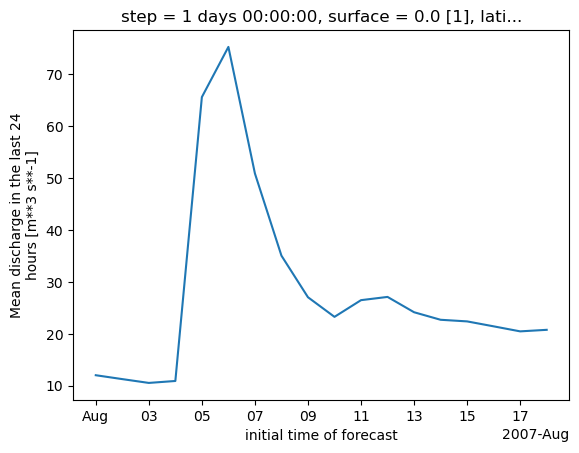

In [27]:
da.sel(time=slice('2007-08-01','2007-08-18')).plot()

### 22 August 2015 

- 3-day lead time (T+72)
- Nothing notable occurred (discharge values are low)

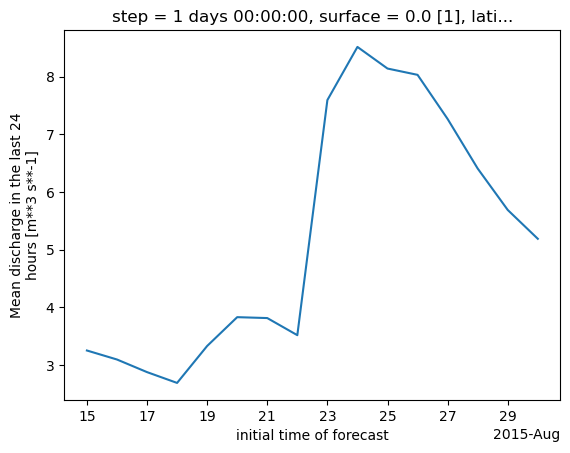

In [17]:
da.sel(time=slice('2015-08-15','2015-08-30')).plot()

### 21 August 2020 

- 5-day lead time (T+120)

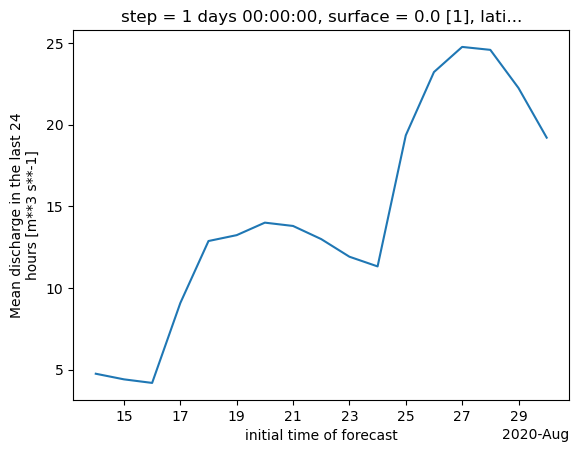

In [19]:
da.sel(time=slice('2020-08-14','2020-08-30')).plot()

### 3 August 2014 

- 6-day lead time (T+144)

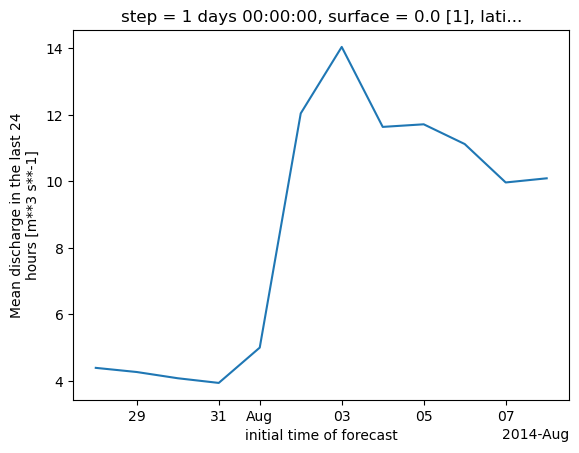

In [20]:
da.sel(time=slice('2014-07-28','2014-08-08')).plot()

### 18 May 2014

- 6-day lead time (T+144)

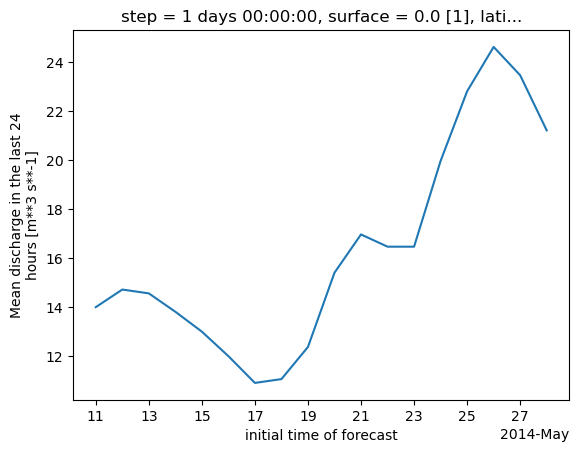

In [25]:
da.sel(time=slice('2014-05-11','2014-05-28')).plot()

### 23 October 2004 

- 7-day lead time (T+168)

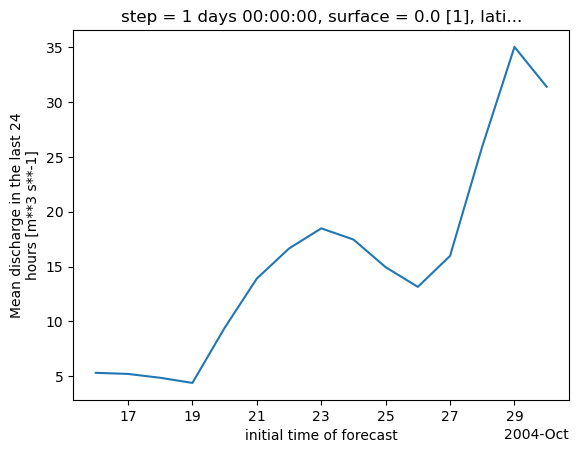

In [28]:
da.sel(time=slice('2004-10-16','2004-10-30')).plot()